<a href="https://colab.research.google.com/github/saritrit66-collab/Final-Project/blob/main/confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

אנא העלה את קובץ האקסל המוכן (אחרי ה-XLOOKUP) עם 600 הרשומות:


Saving ‏‏תוצאות סופיות (1) - מודל.xlsx to ‏‏תוצאות סופיות (1) - מודל.xlsx
הקובץ ‏‏תוצאות סופיות (1) - מודל.xlsx הועלה בהצלחה!

הערה: 1 שורות הוסרו עקב ערכי NaN בעמודות 'Gabriel_Manual_Label' או 'BERT_RF_Predicted'.

------------------------------------------------------------
דיוק כללי (Accuracy) של מודל BERT בהשוואה לסיווג הידני: 71.77%
------------------------------------------------------------

דוח סיווג מפורט (Classification Report):
                precision    recall  f1-score   support

 Normative (0)       0.74      0.90      0.81       417
Conspiracy (1)       0.62      0.35      0.45       203

      accuracy                           0.72       620
     macro avg       0.68      0.62      0.63       620
  weighted avg       0.70      0.72      0.69       620


הגרף נוצר בהצלחה! התמונה 'charlie_kirk_confusion_matrix.png' נשמרה בצד שמאל בתיקיית הקבצים של הקולאב.


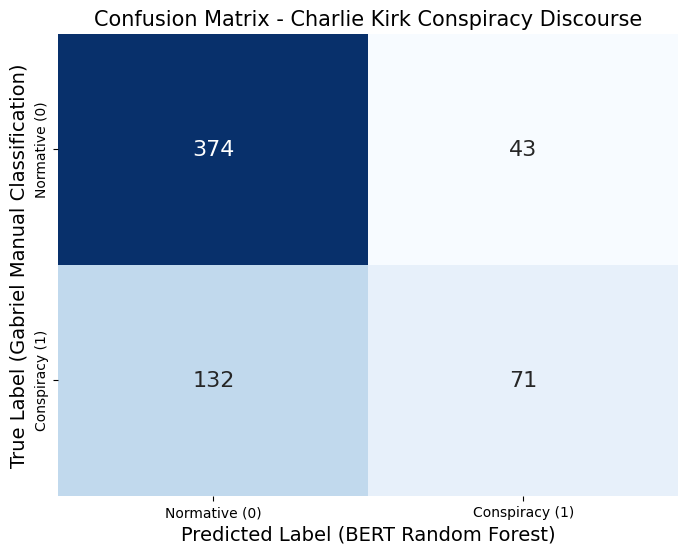

In [ ]:
# ייבוא הספריות הנדרשות
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from google.colab import files
import io

def main():
    print("אנא העלה את קובץ האקסל המוכן (אחרי ה-XLOOKUP) עם 600 הרשומות:")
    # פתיחת חלונית להעלאת הקובץ
    uploaded = files.upload()

    if not uploaded:
        print("לא הועלה קובץ. אנא נסה שנית.")
        return

    file_name = list(uploaded.keys())[0]
    print(f"הקובץ {file_name} הועלה בהצלחה!\n")

    # קריאת הנתונים מהקובץ
    if file_name.endswith('.csv'):
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    else:
        df = pd.read_excel(io.BytesIO(uploaded[file_name]))

    # --- השמות שהגדרת באקסל ---
    true_label_col = 'Gabriel_Manual_Label'       # הסיווג הידני
    predicted_label_col = 'BERT_RF_Predicted'     # סיווג המודל האוטומטי

    # וידוא שהעמודות קיימות בקובץ
    if true_label_col not in df.columns or predicted_label_col not in df.columns:
        print(f"שגיאה: העמודות לא נמצאו. אנא ודא ששמות העמודות באקסל הם בדיוק:")
        print(f"'{true_label_col}' ו- '{predicted_label_col}' (ללא רווחים מיותרים).")
        print("העמודות הקיימות כרגע בקובץ שלך הן:", list(df.columns))
        return

    # חילוץ הנתונים מהעמודות
    y_true_raw = df[true_label_col]
    y_pred_raw = df[predicted_label_col]

    # Handle NaN values: Drop rows where either y_true or y_pred are NaN
    initial_len = len(y_true_raw)
    combined_df = pd.DataFrame({'y_true': y_true_raw, 'y_pred': y_pred_raw})
    combined_df.dropna(subset=['y_true', 'y_pred'], inplace=True)
    y_true = combined_df['y_true']
    y_pred = combined_df['y_pred']

    if len(y_true) < initial_len:
        print(f"הערה: {initial_len - len(y_true)} שורות הוסרו עקב ערכי NaN בעמודות '{true_label_col}' או '{predicted_label_col}'.\n")

    # --- חישוב המדדים ---
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)

    print("-" * 60)
    print(f"דיוק כללי (Accuracy) של מודל BERT בהשוואה לסיווג הידני: {accuracy * 100:.2f}%")
    print("-" * 60)
    print("\nדוח סיווג מפורט (Classification Report):")

    # Dynamically determine target names for classification report and heatmap
    all_labels = np.unique(np.concatenate((y_true, y_pred)))
    # Assuming 0 and 1 are the specific labels expected based on the original target_names
    target_names = []
    for label in all_labels:
        if label == 0:
            target_names.append('Normative (0)')
        elif label == 1:
            target_names.append('Conspiracy (1)')
        else:
            target_names.append(str(label)) # Fallback for unexpected labels

    print(classification_report(y_true, y_pred, target_names=target_names))

    # --- ויזואליזציה (ציור המטריצה) ---
    plt.figure(figsize=(8, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=target_names,
                yticklabels=target_names,
                annot_kws={"size": 16})

    # כותרות מותאמות אישית לפרויקט שלכם
    plt.xlabel('Predicted Label (BERT Random Forest)', fontsize=14)
    plt.ylabel('True Label (Gabriel Manual Classification)', fontsize=14)
    plt.title('Confusion Matrix - Charlie Kirk Conspiracy Discourse', fontsize=15)

    # שמירת הגרף כתמונה
    plt.savefig('charlie_kirk_confusion_matrix.png', dpi=300, bbox_inches='tight')

    print("\nהגרף נוצר בהצלחה! התמונה 'charlie_kirk_confusion_matrix.png' נשמרה בצד שמאל בתיקיית הקבצים של הקולאב.")
    plt.show()

if __name__ == '__main__':
    main()